# Inverse Modeling example

We'll show a simple example for inverse modeling using automatic differentiation on a vertex model with bounded boundaries.

First, let's check that VertAX is correctly installed by importing all we'll need for the next parts

In [ ]:
from __future__ import annotations

from time import perf_counter

import jax
import jax.numpy as jnp
import optax
from jax import Array, vmap

from vertax.bounded import BoundedMesh  # The class for a Vertex Model with bounded boundaries.
from vertax.cost import cost_ratio
from vertax.geo import get_area_bounded, get_edge_length, get_surface_length
from vertax.method_enum import BilevelOptimizationMethod
from vertax.opt_bounded import InnerLossFunctionBounded
from vertax.plot import EdgePlot, FacePlot

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Now, let's create our initial mesh. It will have 20 cells, in a square domain.

In [ ]:
# Settings
n_cells = 20

L_box = jnp.sqrt(n_cells)
width = float(L_box)
height = float(L_box)

# Create a new mesh with periodic boundary conditions, from a Voronoi graph with random seeds positions.
mesh = BoundedMesh.from_random_seeds(nb_seeds=n_cells, width=width, height=height, random_key=2)



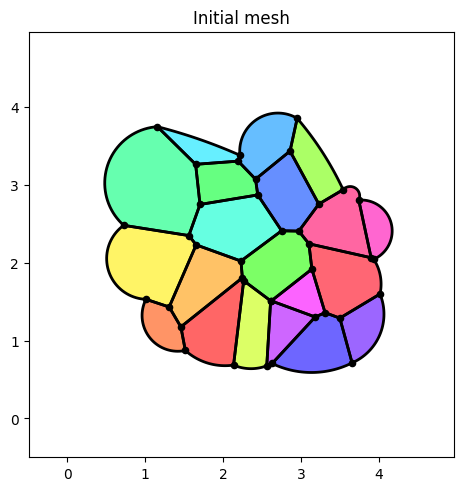

Created mesh has 20 cells, 57 edges and 38 vertices.


In [ ]:
mesh.plot(title="Initial mesh")

print(f"Created mesh has {mesh.nb_faces} cells, {mesh.nb_edges} edges and {mesh.nb_vertices} vertices.")

The mesh is associated to parameters on vertices, (half-)edges and faces (cells). The meaning of these parameters is "given" by the loss functions.

In our example, we'll only focus on the parameters of the edges, which will be the tensions at given edge ; and the parameters for faces will be their area, fixed to 0.6.

In [ ]:
# Set mesh parameters
# 1) We don't use vertices, basic initialization.
mesh.vertices_params = jnp.asarray([0.0 for _ in range(mesh.nb_vertices)])

# 2) We give a random tension to each edge.
key = jax.random.PRNGKey(3)  # change the seed for different results
mesh.edges_params = 1 + jax.nn.sigmoid(jax.random.uniform(key, (mesh.nb_edges,))* 20 - 10)
# As we have half-edges, this part is necessary so that corresponding half-edges have the same tension.
# mesh.edges_params = jnp.repeat(he_params, 2)

# 3) We set the faces areas to 0.6.
mesh.faces_params = jnp.asarray([0.6 for _ in range(mesh.nb_faces)])

It is time to define our custom inner loss function. This energy function will penalize cell areas different than 0.6 and the length of edges depending on the tension on them.

In [ ]:
def get_energy_function() -> InnerLossFunctionBounded:
    """Helper function to get a customized energy function."""

    # Energy functions : Note that they use the width and height parameters defined earlier
    def area_part(
            face: Array, face_param: Array, vertTable: Array, angTable:Array, heTable: Array, faceTable: Array
            ) -> Array:
        """Area part of the energy function, per given faces."""
        a = get_area_bounded(face, vertTable, angTable, heTable, faceTable)
        return (a - face_param) ** 2

    def surface_edge_energy(edge: Array, tension: Array, vertTable: Array, angTable: Array, heTable: Array) -> Array:
        """Edge part of the energy function, for given edge. 0 for inner edges."""
        length = get_surface_length(edge, vertTable, angTable, heTable)
        return length * tension

    def inner_edge_energy(edge: Array, tension: Array, vertTable: Array, heTable: Array) -> Array:
        """Edge part of the energy function, for given edge. 0 for surface edges."""
        length = get_edge_length(edge, vertTable, heTable)
        return length * tension

    # It is important to define the energy function with this exact signature,
    # even though the "_vert_params" is unused, we still keep it.
    def energy_fct(
        vertTable: Array,
        angTable: Array,
        heTable: Array,
        faceTable: Array,
        _selected_verts: Array | None,
        _selected_hes: Array | None,
        _selected_faces: Array | None,
        _vert_params: Array,
        he_params: Array,
        face_params: Array,
    ) -> Array:
        """Custom energy function for the inner optimization. All parameters are required in the signature."""
        # Prepare data first
        # for bounded meshes the two first vertices are reserved values
        vertTable = jnp.vstack([jnp.array([[0.0, 0.0], [1.0, 1.0]]), vertTable])
        num_edges = angTable.size
        num_half_edges = num_edges * 2
        edges = jnp.arange(num_half_edges)
        unique_edges = jnp.arange(num_edges) * 2
        angTable = jnp.repeat(angTable, 2)  # repeat data for twin half-edges
        he_params = jax.nn.sigmoid(he_params) + 1

        K_areas = 20

        def mapped_areas_part(face: Array, face_param: Array) -> Array:
            return area_part(face, face_param, vertTable, angTable, heTable, faceTable)

        cell_area_energies = jnp.sum(vmap(mapped_areas_part)(jnp.arange(len(faceTable)), face_params))

        def mapped_surface_part(he: Array, tension: Array) -> Array:
            return surface_edge_energy(he, tension, vertTable, angTable, heTable)

        surface_edge_energies = jnp.sum(vmap(mapped_surface_part)(
                                                                                edges, jnp.repeat(he_params, 2)
                                                                              ))

        def mapped_inner_part(edge: Array, tension: Array) -> Array:
            return inner_edge_energy(edge, tension, vertTable, heTable)

        inner_edge_energies = jnp.sum(vmap(mapped_inner_part)(unique_edges, he_params))

        return K_areas * cell_area_energies + inner_edge_energies + surface_edge_energies

    return energy_fct

energy = get_energy_function()

Now we are ready to perform the inner optimization !

Here are some parameters that are taken into account with the inner optimization :

In [ ]:
# Note: those are base values so the following can be ommited
mesh.inner_solver = optax.sgd(learning_rate=0.01)  # inner solver
mesh.update_t1 = True # Perform T1 transitions if necessary.
mesh.min_dist_T1 = 0.005  # Threshold to perform the T1 transitions.
mesh.max_nb_iterations = 1000  # Upper bound for the number of minimization operations
mesh.tolerance = 1e-4  # Below this level, we consider that the loss is stagnating
mesh.patience = 5  # Maximum number of consecutive stagnating loss before we stop.

Let's perform the inner optimization. It's as simple as that:

In [ ]:
# Other paramerters are image_target (for cost_mesh2image), beta (for EP).
loss_history = mesh.inner_opt(loss_function_inner=energy)
# If you want to select only a subset of vertices, edges, and faces, it's possible:
# pbc_mesh.inner_opt(
#     loss_function_inner=energy,
#     only_on_vertices=[list_vertex_ids],
#     only_on_edges=[list_edges_id],
#     only_on_faces=[list_faces_id],
# )

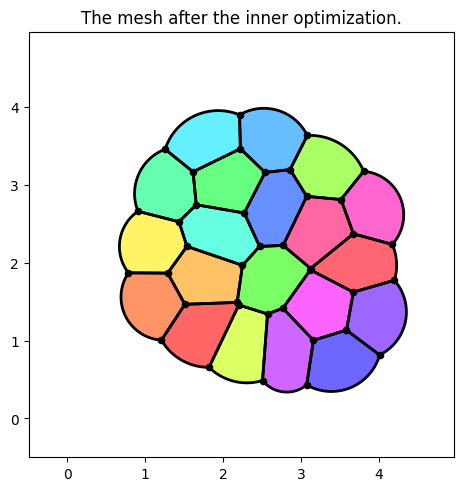

In [ ]:
mesh.plot(title="The mesh after the inner optimization.")

The inner optimization nudged the mesh to minimize the length of edges with high tension while keeping the area of each face close to 0.6.

We'll use a bilevel optimization method now.

In addition to the previous parameters for the inner optimization, the following parameters are used during the bilevel optimization process:

In [ ]:
# Once again this part can be ommited because those are the base value for these parameters
mesh.outer_solver = optax.adam(learning_rate=0.0001, nesterov=True)  # outer solver
mesh.bilevel_optimization_method = BilevelOptimizationMethod.AUTOMATIC_DIFFERENTIATION

Let's run our bilevel optimization process. The first epoch is always a bit long but the next ones will be quick.

In a real simulation, a high number of epochs is necessary for a good result. Here, for this basic tutorial, we'll only use a few epochs.

(Also note that the performances are always worse in a notebook !)

In [ ]:
nb_epochs = 10

cost_history = []
for epoch in range(nb_epochs + 1):
    t_start = perf_counter()
    # This cost defines an approximate ratio between the long and short axes of our cellular cluster ;
    # and compares the current ratio against a fixed target of 2.0,
    # which corresponds to the goal to be achieved in this particular experiment.
    cost = cost_ratio(mesh.vertices)
    cost_history.append(cost)
    print(f"epoch: {epoch}/{nb_epochs}, actual cost is {cost}")

    loss_history = mesh.bilevel_opt(loss_function_inner=energy, loss_function_outer=cost_ratio)
    print(f"epoch {epoch} took {perf_counter() - t_start} seconds.")

epoch: 0/10, actual cost is 0.7472055554389954
epoch 0 took 26.281605277999915 seconds.
epoch: 1/10, actual cost is 0.7465879917144775
epoch 1 took 3.647758265000448 seconds.
epoch: 2/10, actual cost is 0.7459349036216736
epoch 2 took 3.8118331900004705 seconds.
epoch: 3/10, actual cost is 0.7452713847160339
epoch 3 took 3.722599620999972 seconds.
epoch: 4/10, actual cost is 0.7446040511131287
epoch 4 took 3.8824805459989875 seconds.
epoch: 5/10, actual cost is 0.743933916091919
epoch 5 took 3.830387370999233 seconds.
epoch: 6/10, actual cost is 0.7432639002799988
epoch 6 took 3.6383336750004673 seconds.
epoch: 7/10, actual cost is 0.74259352684021
epoch 7 took 3.6896403250011645 seconds.
epoch: 8/10, actual cost is 0.741924524307251
epoch 8 took 3.67193378400043 seconds.
epoch: 9/10, actual cost is 0.7412570714950562
epoch 9 took 3.7872476120010106 seconds.
epoch: 10/10, actual cost is 0.7405927777290344
epoch 10 took 3.8069552809993183 seconds.


Just to check that the process is working, let's do a basic plot of the cost in function of the epoch.

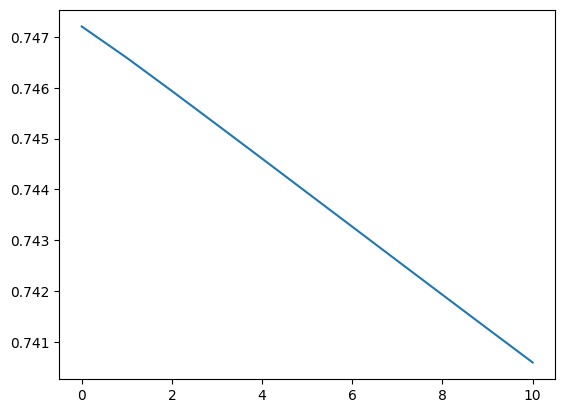

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(nb_epochs+1), cost_history)

Of course, a higher number of epochs is necessary for the cost function to stabilize. If we plot the mesh after a sufficient number of epochs, we'll see that the vertices moved to match the tensions and area constraints.

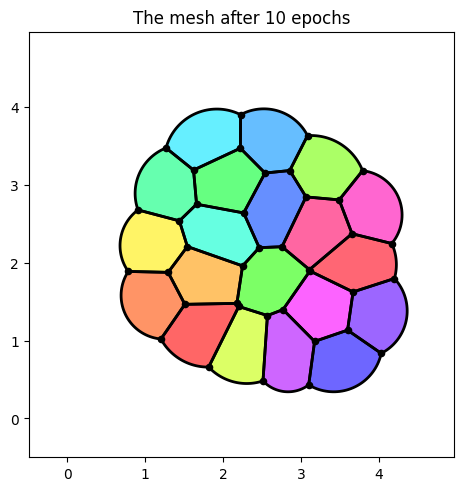

In [ ]:
mesh.plot(title=f"The mesh after {nb_epochs} epochs")

We can also plot the tensions and areas:

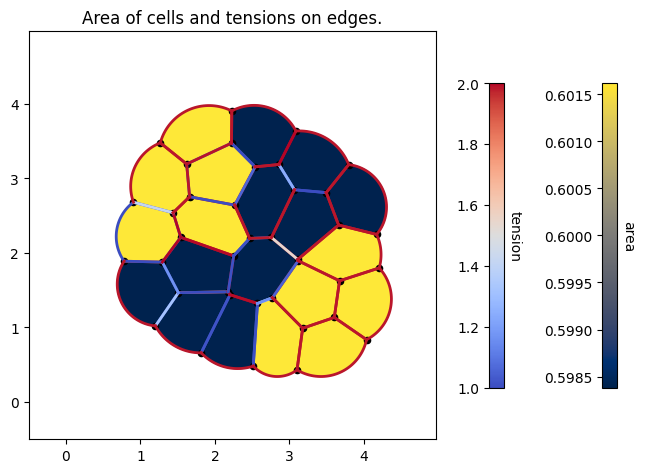

In [ ]:
mesh.plot(edge_plot=EdgePlot.EDGE_PARAMETER, edge_parameters_name="tension",
          face_plot=FacePlot.FACE_PARAMETER, face_parameters_name="area",
          title="Area of cells and tensions on edges.")